# DATA 266 Lab 1 — Task 1  
## Character-Level GPT on TinyStories

**Student:** Omkar Rajale  
**SID4:** 0298  
**SEED:** 298  
**SLICE:** 298  
**HP_ID:** 4  
**CLS_A:** 8  
**CLS_B:** 1  

In [7]:
from datetime import datetime, timezone

print("Execution timestamp:", datetime.now(timezone.utc).isoformat())

Execution timestamp: 2026-09-18T22:23:13.455651+00:00


In [8]:
pip install datasets nltk

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 803.0/803.0 kB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [nltk]3/4 [nltk]
Note: you may need to restart the kernel to use updated packages.


In [9]:
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset

/opt/conda/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Setting up HF Token

In [15]:
from getpass import getpass
from huggingface_hub import whoami

hf_token = getpass("Enter your Hugging Face token: ")

print("Authenticated as:", whoami(token=hf_token)["name"])

Enter your Hugging Face token:  ········


Authenticated as: rajaleomkar14


## Loading Yelp-Polarity dataset from hf

In [12]:
dataset = load_dataset("fancyzhx/yelp_polarity")

## Train-test Split

In [14]:
train_data = dataset["train"]
test_data = dataset["test"]

print(f"Train samples: {len(train_data):,}")
print(f"Test samples : {len(test_data):,}")

Train samples: 560,000
Test samples : 38,000


## Filtering empty & None texts entries

In [16]:
clean_train_data = train_data.filter(lambda x: x["text"] is not None and len(x["text"].strip()) > 0)
print(f"Valid samples after filtering: {len(clean_train_data):,}")

Filter: 100%|██████████| 560000/560000 [00:00<00:00, 1278730.33 examples/s]

Valid samples after filtering: 560,000


## Checking class balance

In [17]:
labels = np.array(clean_train_data["label"])
unique, counts = np.unique(labels, return_counts=True)
for u, c in zip(unique, counts):
    sentiment = "Negative (0)" if u == 0 else "Positive (1)"
    print(f"Class {sentiment}: {c:,} samples ({c / len(labels) * 100:.2f}%)")

Class Negative (0): 280,000 samples (50.00%)
Class Positive (1): 280,000 samples (50.00%)


## Review length distributions

In [20]:
sample_texts = clean_train_data["text"][:]
word_counts = [len(t.split()) for t in sample_texts]

print("\nReview Length Statistics (Word Count):")
print(f"Mean word count: {np.mean(word_counts):.1f}")
print(f"Median (50th percentile): {np.percentile(word_counts, 50):.0f}")
print(f"95th percentile: {np.percentile(word_counts, 95):.0f}")
print(f"Max word count : {np.max(word_counts)}")


Review Length Statistics (Word Count):
Mean word count: 133.0
Median (50th percentile): 97
95th percentile: 372
Max word count : 1052


## Plotting the Yelp review length distribution

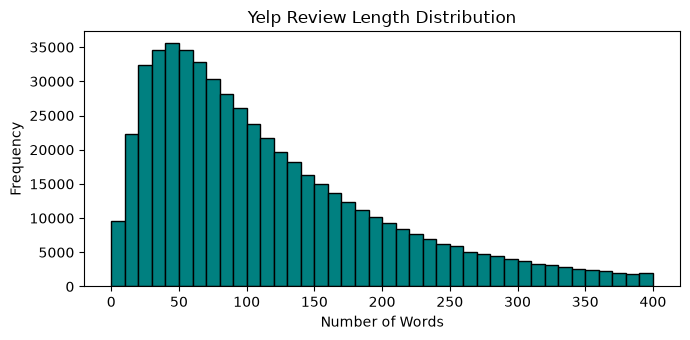

In [21]:
plt.figure(figsize=(7, 3.5))
plt.hist(word_counts, bins=40, range=(0, 400), color="teal", edgecolor="black")
plt.title("Yelp Review Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

## Text Preprocessing

In [37]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [38]:
nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)

True

In [39]:
stop_words = set(stopwords.words("english"))
#negations = {"not", "no", "nor", "neither", "never", "barely", "hardly"}
#custom_stopwords = stop_words - negations

In [40]:
lemmatizer = WordNetLemmatizer()

def clean_and_preprocess(text):
    # 3a. Lowercase
    text = text.lower()
    
    # 3b. Remove punctuation and numbers
    text = re.sub(r"[^a-z\s]", " ", text)
    
    # 4. Tokenize
    raw_tokens = text.strip().split()
    
    # 3c & 3d. Stopword removal and lemmatization
    cleaned_tokens = [
        lemmatizer.lemmatize(word)
        for word in raw_tokens
        if word not in custom_stopwords and len(word) > 1
    ]
    return cleaned_tokens

In [41]:
# Test example
test_review = "The food wasn't great, service was totally horrible!"
print("Original :", test_review)
print("Processed:", clean_and_preprocess(test_review))

Original : The food wasn't great, service was totally horrible!
Processed: ['food', 'great', 'service', 'totally', 'horrible']


"Failure Type: Preprocessing Artifact / Negation Loss. Naive stopword filtering stripped the negation from 'wasn't great', forcing the model to evaluate only the positive token 'great'.

## Vocabulary & Tokenization from Scratch

In [42]:
from collections import Counter

In [43]:
# initially testing for a sample set of 30000 reviews

class ScratchVocab:
    def __init__(self, max_size=30000):
        self.pad_token = "<PAD>"  # ID 0
        self.unk_token = "<UNK>"  # ID 1
        self.word2idx = {self.pad_token: 0, self.unk_token: 1}
        self.idx2word = {0: self.pad_token, 1: self.unk_token}
        self.max_size = max_size

    def build_vocab(self, list_of_token_lists):
        counter = Counter()
        for tokens in list_of_token_lists:
            counter.update(tokens)
        
        # Take the most frequent words up to max_size
        for word, _ in counter.most_common(self.max_size - 2):
            idx = len(self.word2idx)
            self.word2idx[word] = idx
            self.idx2word[idx] = word

    def encode(self, tokens, max_len=256):
        # Convert tokens to integers and pad/truncate to fixed length
        ids = [self.word2idx.get(w, self.word2idx[self.unk_token]) for w in tokens]
        if len(ids) < max_len:
            ids += [self.word2idx[self.pad_token]] * (max_len - len(ids))
        else:
            ids = ids[:max_len]
        return ids

In [44]:
subset_texts = clean_train_data["text"][:30000]
tokenized_subset = [clean_and_preprocess(t) for t in subset_texts]

vocab = ScratchVocab(max_size=30000)
vocab.build_vocab(tokenized_subset)

print(f"Vocabulary size: {len(vocab.word2idx)}")
print("Sample word mappings:", list(vocab.word2idx.items())[:6])

Vocabulary size: 30000
Sample word mappings: [('<PAD>', 0), ('<UNK>', 1), ('not', 2), ('place', 3), ('food', 4), ('good', 5)]


## Learned Textual Embeddings from Scratch

In [49]:
import torch
import torch.nn as nn

In [50]:
class ScratchEmbedding(nn.Module):
    def __init__(self, vocab_size, embedding_dim=128, pad_idx=0):
        super().__init__()
        # PyTorch initializes weights randomly by default — learned completely from scratch
        self.embedding = nn.Embedding(
            num_embeddings=vocab_size, 
            embedding_dim=embedding_dim, 
            padding_idx=pad_idx
        )

    def forward(self, x):
        # Input:  (batch_size, seq_len)
        # Output: (batch_size, seq_len, embedding_dim)
        return self.embedding(x)

In [51]:
# Verification:
embed_layer = ScratchEmbedding(vocab_size=len(vocab.word2idx), embedding_dim=128)

In [53]:
# 2. Encode the first tokenized review from your Hugging Face subset
sample_encoded = vocab.encode(tokenized_subset[0], max_len=256)

# 3. Create input tensor and pass through the embedding layer
input_tensor = torch.tensor([sample_encoded], dtype=torch.long)
embedded_output = embed_layer(input_tensor)

print("Input sequence shape :", input_tensor.shape)
print("Scratch embedded shape:", embedded_output.shape)

Input sequence shape : torch.Size([1, 256])
Scratch embedded shape: torch.Size([1, 256, 128])


# Model Training and Evaluation

In [56]:
from torch.utils.data import Dataset, DataLoader

In [57]:
class YelpTorchDataset(Dataset):
    def __init__(self, hf_dataset, vocab, max_len=256):
        self.dataset = hf_dataset
        self.vocab = vocab
        self.max_len = max_len

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        item = self.dataset[idx]
        tokens = clean_and_preprocess(item["text"])
        encoded = self.vocab.encode(tokens, max_len=self.max_len)
        return {
            "input_ids": torch.tensor(encoded, dtype=torch.long),
            "label": torch.tensor(item["label"], dtype=torch.float32),
            "text": item["text"]
        }

In [58]:
# Create Train and Test datasets
# Using clean_train_data and test_data from earlier Hugging Face load
train_dataset = YelpTorchDataset(clean_train_data, vocab, max_len=256)
test_dataset = YelpTorchDataset(test_data, vocab, max_len=256)

# DataLoaders
train_loader = DataLoader(
    train_dataset, 
    batch_size=512, 
    shuffle=True, 
    num_workers=4, 
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset, 
    batch_size=512, 
    shuffle=False, 
    num_workers=4, 
    pin_memory=True
)

print(f"DataLoaders ready! Batches per train epoch: {len(train_loader):,}")

DataLoaders ready! Batches per train epoch: 1,094


## Defining base model

In [59]:
# Baseline Model: Global Average Pooling (FastText-style)
class FastTextBaseline(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, pad_idx=0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.fc = nn.Linear(embed_dim, 1)

    def forward(self, x):
        # x shape: (batch_size, seq_len)
        embedded = self.embedding(x)                 # (batch_size, seq_len, embed_dim)
        pooled = torch.mean(embedded, dim=1)        # (batch_size, embed_dim)
        logits = self.fc(pooled)                    # (batch_size, 1)
        return logits.squeeze(-1)

# Instantiate and verify on GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
baseline_model = FastTextBaseline(vocab_size=len(vocab.word2idx), embed_dim=128).to(device)

total_params = sum(p.numel() for p in baseline_model.parameters() if p.requires_grad)
print(f"Baseline Model initialized on: {device}")
print(f"Total Trainable Parameters: {total_params:,}")

Baseline Model initialized on: cuda
Total Trainable Parameters: 3,840,129


## Logging & Checkpoint Setup

In [60]:
import os
import time
import json
import logging
from pathlib import Path

# Setup folder paths according to submission guidelines
MEMBER_NAME = "Omkar_Rajale"  # Use your folder identifier
BASE_DIR = Path(f"task2_sentiment/{MEMBER_NAME}")
LOG_DIR = Path("reproducibility/raw_logs")
MANIFEST_DIR = Path("reproducibility/manifests")

for folder in [BASE_DIR / "checkpoints", BASE_DIR / "outputs", LOG_DIR, MANIFEST_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

# Configure raw logger for training evidence trail
logger = logging.getLogger("Task2_Logger")
logger.setLevel(logging.INFO)
logger.handlers.clear()

fh = logging.FileHandler(LOG_DIR / f"task2_{MEMBER_NAME}_raw_training.log", mode="a")
ch = logging.StreamHandler()
formatter = logging.Formatter("[%(asctime)s] [%(levelname)s] %(message)s", datefmt="%Y-%m-%d %H:%M:%S")
fh.setFormatter(formatter)
ch.setFormatter(formatter)
logger.addHandler(fh)
logger.addHandler(ch)

logger.info(f"Initialized training session for {MEMBER_NAME}")
logger.info(f"Using device: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")

[2026-09-19 00:03:53] [INFO] Initialized training session for Omkar_Rajale
[2026-09-19 00:03:53] [INFO] Using device: NVIDIA GeForce RTX 5090


## Training & Hardware profiling

In [61]:
def train_model(model_name, model, dataloader, epochs=5, lr=1e-3):
    model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    criterion = nn.BCEWithLogitsLoss()
    
    torch.cuda.reset_peak_memory_stats(device)
    param_count = sum(p.numel() for p in model.parameters() if p.requires_grad)
    
    logger.info(f"--- START TRAINING: {model_name} ---")
    logger.info(f"Parameters: {param_count:,} | Epochs: {epochs} | LR: {lr}")
    
    start_time = time.time()
    
    for epoch in range(1, epochs + 1):
        epoch_start = time.time()
        model.train()
        running_loss = 0.0
        
        for step, batch in enumerate(dataloader, 1):
            inputs = batch["input_ids"].to(device, non_blocking=True)
            labels = batch["label"].to(device, non_blocking=True)
            
            optimizer.zero_grad(set_to_none=True)
            with torch.amp.autocast(device_type="cuda", dtype=torch.bfloat16):
                logits = model(inputs)
                loss = criterion(logits, labels)
                
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            
            if step % 200 == 0 or step == len(dataloader):
                logger.info(f"[{model_name}] Epoch {epoch}/{epochs} | Step {step}/{len(dataloader)} | Loss: {loss.item():.4f}")
        
        epoch_dur = time.time() - epoch_start
        avg_loss = running_loss / len(dataloader)
        logger.info(f"[{model_name}] Epoch {epoch} complete in {epoch_dur:.2f}s | Avg Loss: {avg_loss:.4f}")

    total_time = time.time() - start_time
    peak_vram = torch.cuda.max_memory_allocated(device) / (1024 ** 3)
    throughput = (len(dataloader.dataset) * epochs) / total_time
    
    # Save checkpoint
    checkpoint_path = BASE_DIR / "checkpoints" / f"{model_name}.pt"
    torch.save(model.state_dict(), checkpoint_path)
    logger.info(f"Saved weights to {checkpoint_path}")
    
    return {
        "param_count": param_count,
        "train_time_sec": total_time,
        "examples_per_sec": throughput,
        "peak_vram_gb": peak_vram,
        "checkpoint": str(checkpoint_path)
    }

# Run training on Baseline Model
baseline_profile = train_model("FastText_Baseline", baseline_model, train_loader, epochs=5)

[2026-09-19 00:04:11] [INFO] --- START TRAINING: FastText_Baseline ---
[2026-09-19 00:04:11] [INFO] Parameters: 3,840,129 | Epochs: 5 | LR: 0.001
[2026-09-19 00:04:17] [INFO] [FastText_Baseline] Epoch 1/5 | Step 200/1094 | Loss: 0.5846
[2026-09-19 00:04:22] [INFO] [FastText_Baseline] Epoch 1/5 | Step 400/1094 | Loss: 0.4259
[2026-09-19 00:04:27] [INFO] [FastText_Baseline] Epoch 1/5 | Step 600/1094 | Loss: 0.3370
[2026-09-19 00:04:31] [INFO] [FastText_Baseline] Epoch 1/5 | Step 800/1094 | Loss: 0.2871
[2026-09-19 00:04:35] [INFO] [FastText_Baseline] Epoch 1/5 | Step 1000/1094 | Loss: 0.2619
[2026-09-19 00:04:37] [INFO] [FastText_Baseline] Epoch 1/5 | Step 1094/1094 | Loss: 0.2434
[2026-09-19 00:04:37] [INFO] [FastText_Baseline] Epoch 1 complete in 26.67s | Avg Loss: 0.4101
[2026-09-19 00:04:42] [INFO] [FastText_Baseline] Epoch 2/5 | Step 200/1094 | Loss: 0.2271
[2026-09-19 00:04:47] [INFO] [FastText_Baseline] Epoch 2/5 | Step 400/1094 | Loss: 0.2170
[2026-09-19 00:04:52] [INFO] [FastTex

## Metrics Evaluation

In [65]:
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    roc_auc_score,
    precision_recall_curve,
    auc,
    brier_score_loss,
    matthews_corrcoef,
    confusion_matrix
)

def compute_ece(probs, labels, n_bins=10):
    bin_boundaries = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    for i in range(n_bins):
        bin_idx = (probs > bin_boundaries[i]) & (probs <= bin_boundaries[i + 1])
        if np.sum(bin_idx) > 0:
            bin_acc = np.mean(labels[bin_idx])
            bin_conf = np.mean(probs[bin_idx])
            ece += (np.sum(bin_idx) / len(probs)) * np.abs(bin_acc - bin_conf)
    return ece

def bootstrap_ci(labels, preds, n_bootstraps=300):
    accs, f1s, mccs = [], [], []
    n = len(labels)
    for _ in range(n_bootstraps):
        idx = np.random.choice(n, size=n, replace=True)
        s_y, s_p = labels[idx], preds[idx]
        accs.append(accuracy_score(s_y, s_p))
        _, _, f1, _ = precision_recall_fscore_support(s_y, s_p, average="macro", zero_division=0)
        f1s.append(f1)
        mccs.append(matthews_corrcoef(s_y, s_p))
    return {
        "acc_ci": (np.percentile(accs, 2.5), np.percentile(accs, 97.5)),
        "f1_ci": (np.percentile(f1s, 2.5), np.percentile(f1s, 97.5)),
        "mcc_ci": (np.percentile(mccs, 2.5), np.percentile(mccs, 97.5))
    }

def evaluate(model, dataloader):
    model.eval()
    all_preds, all_probs, all_labels = [], [], []
    
    with torch.no_grad():
        for batch in dataloader:
            inputs = batch["input_ids"].to(device, non_blocking=True)
            labels = batch["label"].cpu().numpy()
            
            with torch.amp.autocast(device_type="cuda", dtype=torch.bfloat16):
                logits = model(inputs)
                probs = torch.sigmoid(logits).float().cpu().numpy()
                
            preds = (probs >= 0.5).astype(int)
            all_probs.extend(probs)
            all_preds.extend(preds)
            all_labels.extend(labels)
            
    y_true = np.array(all_labels)
    y_pred = np.array(all_preds)
    y_prob = np.array(all_probs)
    
    p_macro, r_macro, f1_macro, _ = precision_recall_fscore_support(y_true, y_pred, average="macro")
    p_micro, r_micro, f1_micro, _ = precision_recall_fscore_support(y_true, y_pred, average="micro")
    p_weighted, r_weighted, f1_weighted, _ = precision_recall_fscore_support(y_true, y_pred, average="weighted")
    pr_curve_p, pr_curve_r, _ = precision_recall_curve(y_true, y_prob)
    
    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "f1_macro": f1_macro,
        "f1_micro": f1_micro,
        "f1_weighted": f1_weighted,
        "precision_macro": p_macro,
        "recall_macro": r_macro,
        "mcc": matthews_corrcoef(y_true, y_pred),
        "roc_auc": roc_auc_score(y_true, y_prob),
        "pr_auc": auc(pr_curve_r, pr_curve_p),
        "brier_score": brier_score_loss(y_true, y_prob),
        "ece": compute_ece(y_prob, y_true),
        "confusion_matrix": confusion_matrix(y_true, y_pred).tolist(),
        "bootstrap": bootstrap_ci(y_true, y_pred)
    }
    return metrics, y_true, y_pred, y_prob

print("Evaluating Baseline Model on Test Set...")
baseline_metrics, y_true, baseline_preds, baseline_probs = evaluate(baseline_model, test_loader)

print(f"Accuracy: {baseline_metrics['accuracy']:.4f}")
print(f"Macro F1: {baseline_metrics['f1_macro']:.4f}")
print(f"ROC-AUC : {baseline_metrics['roc_auc']:.4f}")

Evaluating Baseline Model on Test Set...
Accuracy: 0.9355
Macro F1: 0.9355
ROC-AUC : 0.9790


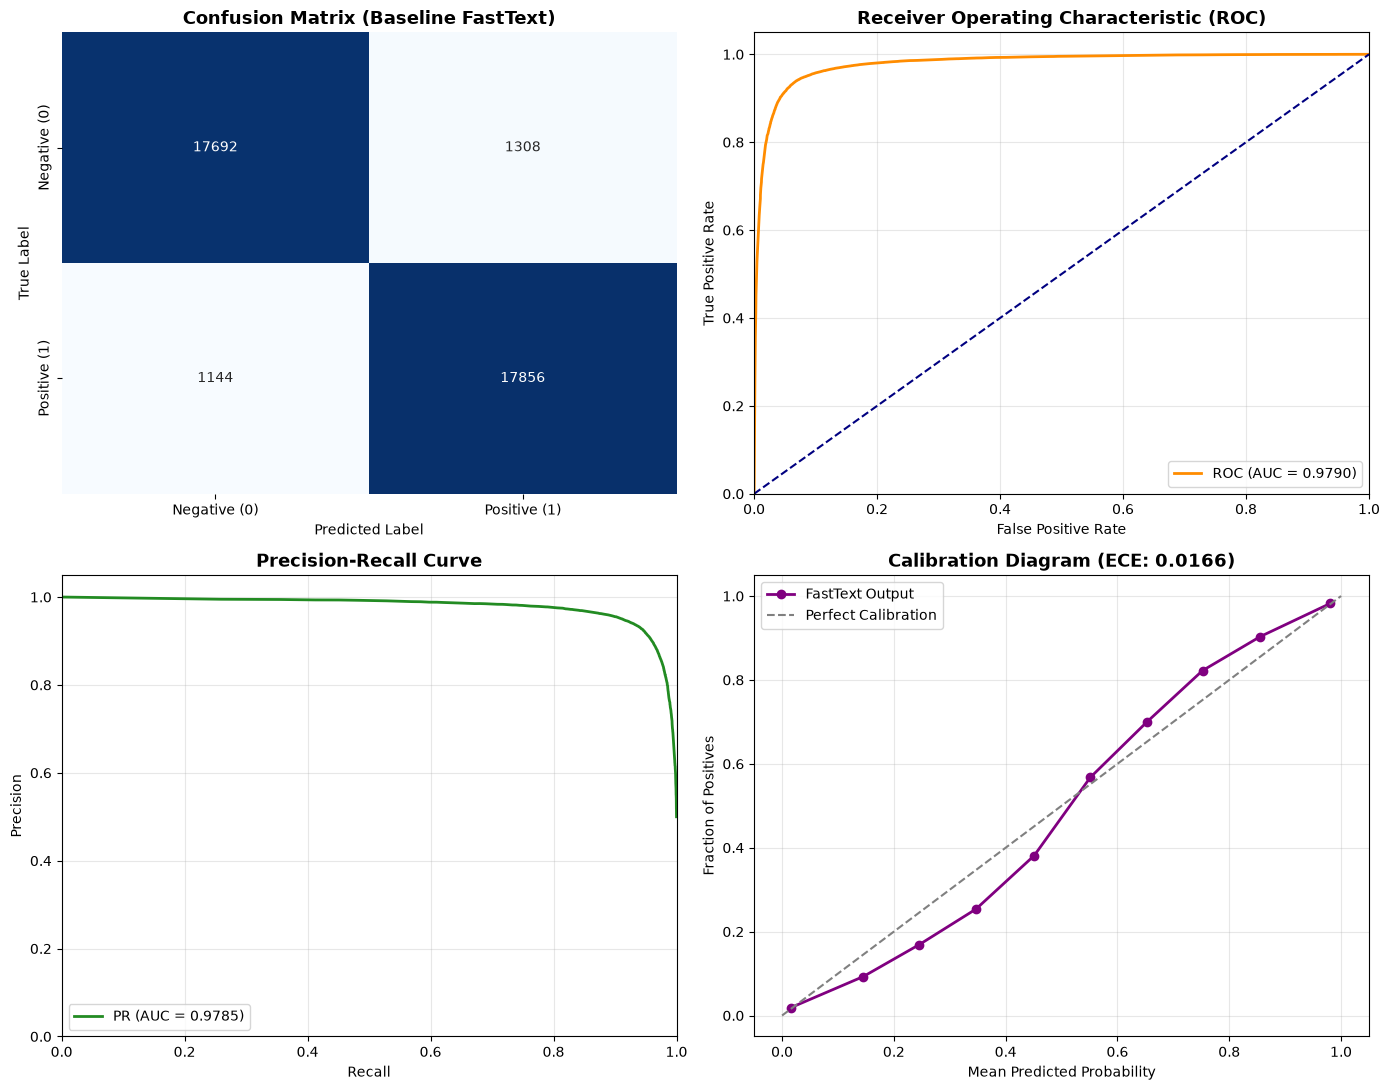

In [68]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, precision_recall_curve, confusion_matrix
from sklearn.calibration import calibration_curve

# Setup 2x2 plot grid
fig, axes = plt.subplots(2, 2, figsize=(14, 11))

# 1. Confusion Matrix
cm = confusion_matrix(y_true, baseline_preds)
sns.heatmap(
    cm, 
    annot=True, 
    fmt="d", 
    cmap="Blues", 
    cbar=False,
    xticklabels=["Negative (0)", "Positive (1)"],
    yticklabels=["Negative (0)", "Positive (1)"],
    ax=axes[0, 0]
)
axes[0, 0].set_title("Confusion Matrix (Baseline FastText)", fontsize=13, fontweight="bold")
axes[0, 0].set_xlabel("Predicted Label")
axes[0, 0].set_ylabel("True Label")

# 2. ROC Curve
fpr, tpr, _ = roc_curve(y_true, baseline_probs)
axes[0, 1].plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC (AUC = {baseline_metrics['roc_auc']:.4f})")
axes[0, 1].plot([0, 1], [0, 1], color="navy", lw=1.5, linestyle="--")
axes[0, 1].set_xlim([0.0, 1.0])
axes[0, 1].set_ylim([0.0, 1.05])
axes[0, 1].set_title("Receiver Operating Characteristic (ROC)", fontsize=13, fontweight="bold")
axes[0, 1].set_xlabel("False Positive Rate")
axes[0, 1].set_ylabel("True Positive Rate")
axes[0, 1].legend(loc="lower right")
axes[0, 1].grid(alpha=0.3)

# 3. Precision-Recall Curve
prec, rec, _ = precision_recall_curve(y_true, baseline_probs)
axes[1, 0].plot(rec, prec, color="forestgreen", lw=2, label=f"PR (AUC = {baseline_metrics['pr_auc']:.4f})")
axes[1, 0].set_xlim([0.0, 1.0])
axes[1, 0].set_ylim([0.0, 1.05])
axes[1, 0].set_title("Precision-Recall Curve", fontsize=13, fontweight="bold")
axes[1, 0].set_xlabel("Recall")
axes[1, 0].set_ylabel("Precision")
axes[1, 0].legend(loc="lower left")
axes[1, 0].grid(alpha=0.3)

# 4. Calibration Curve (Reliability Diagram for ECE & Brier Score)
prob_true, prob_pred = calibration_curve(y_true, baseline_probs, n_bins=10)
axes[1, 1].plot(prob_pred, prob_true, marker="o", linewidth=2, color="purple", label="FastText Output")
axes[1, 1].plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfect Calibration")
axes[1, 1].set_title(f"Calibration Diagram (ECE: {baseline_metrics['ece']:.4f})", fontsize=13, fontweight="bold")
axes[1, 1].set_xlabel("Mean Predicted Probability")
axes[1, 1].set_ylabel("Fraction of Positives")
axes[1, 1].legend(loc="upper left")
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("task2_sentiment/omkar_rajale/outputs/baseline_evaluation_plots.png", dpi=300)
plt.show()

## Define the TextCNN Architecture

In [69]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class TextCNN(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, num_filters=100, filter_sizes=[3, 4, 5], dropout=0.5, pad_idx=0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        
        # Parallel 1D convolutions: kernel sizes 3, 4, 5 capture 3-gram, 4-gram, and 5-gram features
        self.convs = nn.ModuleList([
            nn.Conv1d(in_channels=embed_dim, out_channels=num_filters, kernel_size=fs)
            for fs in filter_sizes
        ])
        
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(len(filter_sizes) * num_filters, 1)

    def forward(self, x):
        # x shape: (batch_size, seq_len)
        embedded = self.embedding(x)                     # (batch_size, seq_len, embed_dim)
        embedded = embedded.permute(0, 2, 1)            # (batch_size, embed_dim, seq_len) for Conv1d
        
        # Apply Conv1d -> ReLU -> Global Max Pooling across time dimension
        conv_outs = []
        for conv in self.convs:
            c = F.relu(conv(embedded))                  # (batch_size, num_filters, seq_len - fs + 1)
            p = F.max_pool1d(c, kernel_size=c.shape[2]).squeeze(2) # (batch_size, num_filters)
            conv_outs.append(p)
            
        # Concatenate pooled features from all filter sizes
        cat = torch.cat(conv_outs, dim=1)               # (batch_size, len(filter_sizes) * num_filters)
        dropped = self.dropout(cat)
        logits = self.fc(dropped)                       # (batch_size, 1)
        return logits.squeeze(-1)

# Instantiate and verify TextCNN
text_cnn_model = TextCNN(vocab_size=len(vocab.word2idx), embed_dim=128, num_filters=100, filter_sizes=[3, 4, 5]).to(device)
total_cnn_params = sum(p.numel() for p in text_cnn_model.parameters() if p.requires_grad)
print(f"TextCNN Model initialized on: {device}")
print(f"Total Trainable Parameters: {total_cnn_params:,}")

TextCNN Model initialized on: cuda
Total Trainable Parameters: 3,994,201


In [70]:
cnn_profile = train_model(
    model_name="TextCNN_Exp1",
    model=text_cnn_model,
    dataloader=train_loader,
    epochs=5,
    lr=1e-3
)

[2026-09-19 00:50:33] [INFO] --- START TRAINING: TextCNN_Exp1 ---
[2026-09-19 00:50:34] [INFO] Parameters: 3,994,201 | Epochs: 5 | LR: 0.001
[2026-09-19 00:50:40] [INFO] [TextCNN_Exp1] Epoch 1/5 | Step 200/1094 | Loss: 0.3258
[2026-09-19 00:50:44] [INFO] [TextCNN_Exp1] Epoch 1/5 | Step 400/1094 | Loss: 0.2377
[2026-09-19 00:50:48] [INFO] [TextCNN_Exp1] Epoch 1/5 | Step 600/1094 | Loss: 0.2498
[2026-09-19 00:50:53] [INFO] [TextCNN_Exp1] Epoch 1/5 | Step 800/1094 | Loss: 0.2267
[2026-09-19 00:50:57] [INFO] [TextCNN_Exp1] Epoch 1/5 | Step 1000/1094 | Loss: 0.2461
[2026-09-19 00:50:59] [INFO] [TextCNN_Exp1] Epoch 1/5 | Step 1094/1094 | Loss: 0.1972
[2026-09-19 00:50:59] [INFO] [TextCNN_Exp1] Epoch 1 complete in 25.77s | Avg Loss: 0.2930
[2026-09-19 00:51:04] [INFO] [TextCNN_Exp1] Epoch 2/5 | Step 200/1094 | Loss: 0.1915
[2026-09-19 00:51:08] [INFO] [TextCNN_Exp1] Epoch 2/5 | Step 400/1094 | Loss: 0.1682
[2026-09-19 00:51:13] [INFO] [TextCNN_Exp1] Epoch 2/5 | Step 600/1094 | Loss: 0.1775
[2

In [71]:
print("Evaluating TextCNN on Test Set...")
cnn_metrics, _, cnn_preds, cnn_probs = evaluate(text_cnn_model, test_loader)

print("\n--- PERFORMANCE COMPARISON ---")
print(f"Baseline (FastText) Accuracy: {baseline_metrics['accuracy']:.4f} | ROC-AUC: {baseline_metrics['roc_auc']:.4f}")
print(f"TextCNN (Exp 1)    Accuracy: {cnn_metrics['accuracy']:.4f} | ROC-AUC: {cnn_metrics['roc_auc']:.4f}")

Evaluating TextCNN on Test Set...

--- PERFORMANCE COMPARISON ---
Baseline (FastText) Accuracy: 0.9355 | ROC-AUC: 0.9790
TextCNN (Exp 1)    Accuracy: 0.9433 | ROC-AUC: 0.9862


## Define the Transformer Encoder Architecture

In [72]:
import math

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=512):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1), :]

class ScratchTransformer(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, nhead=4, num_layers=2, dim_feedforward=256, dropout=0.2, pad_idx=0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.pos_encoder = PositionalEncoding(embed_dim, max_len=512)
        
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            activation="gelu",
            batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(embed_dim, 64),
            nn.GELU(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        padding_mask = (x == 0)
        embedded = self.embedding(x)
        encoded = self.pos_encoder(embedded)
        transformed = self.transformer_encoder(encoded, src_key_padding_mask=padding_mask)
        
        # Masked average pooling across non-padding tokens
        mask = (~padding_mask).unsqueeze(-1).float()
        pooled = (transformed * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1.0)
        logits = self.classifier(pooled)
        return logits.squeeze(-1)

# Instantiate and verify Transformer
transformer_model = ScratchTransformer(vocab_size=len(vocab.word2idx), embed_dim=128, nhead=4, num_layers=2).to(device)
total_tr_params = sum(p.numel() for p in transformer_model.parameters() if p.requires_grad)
print(f"Transformer Model initialized on: {device}")
print(f"Total Trainable Parameters: {total_tr_params:,}")

Transformer Model initialized on: cuda
Total Trainable Parameters: 4,113,281


In [73]:
transformer_profile = train_model(
    model_name="Transformer_Exp2",
    model=transformer_model,
    dataloader=train_loader,
    epochs=5,
    lr=5e-4
)

[2026-09-19 00:54:21] [INFO] --- START TRAINING: Transformer_Exp2 ---
[2026-09-19 00:54:21] [INFO] Parameters: 4,113,281 | Epochs: 5 | LR: 0.0005
[2026-09-19 00:54:26] [INFO] [Transformer_Exp2] Epoch 1/5 | Step 200/1094 | Loss: 0.2966
[2026-09-19 00:54:31] [INFO] [Transformer_Exp2] Epoch 1/5 | Step 400/1094 | Loss: 0.2691
[2026-09-19 00:54:35] [INFO] [Transformer_Exp2] Epoch 1/5 | Step 600/1094 | Loss: 0.2116
[2026-09-19 00:54:40] [INFO] [Transformer_Exp2] Epoch 1/5 | Step 800/1094 | Loss: 0.2129
[2026-09-19 00:54:44] [INFO] [Transformer_Exp2] Epoch 1/5 | Step 1000/1094 | Loss: 0.1781
[2026-09-19 00:54:46] [INFO] [Transformer_Exp2] Epoch 1/5 | Step 1094/1094 | Loss: 0.1701
[2026-09-19 00:54:46] [INFO] [Transformer_Exp2] Epoch 1 complete in 25.00s | Avg Loss: 0.2641
[2026-09-19 00:54:51] [INFO] [Transformer_Exp2] Epoch 2/5 | Step 200/1094 | Loss: 0.2040
[2026-09-19 00:54:55] [INFO] [Transformer_Exp2] Epoch 2/5 | Step 400/1094 | Loss: 0.2101
[2026-09-19 00:55:00] [INFO] [Transformer_Exp2

In [74]:
print("Evaluating Transformer on Test Set...")
transformer_metrics, _, transformer_preds, transformer_probs = evaluate(transformer_model, test_loader)

print("\n--- PERFORMANCE SUMMARY (3 MODELS) ---")
print(f"Baseline (FastText)   Accuracy: {baseline_metrics['accuracy']:.4f} | ROC-AUC: {baseline_metrics['roc_auc']:.4f}")
print(f"TextCNN (Exp 1)       Accuracy: {cnn_metrics['accuracy']:.4f} | ROC-AUC: {cnn_metrics['roc_auc']:.4f}")
print(f"Transformer (Exp 2)   Accuracy: {transformer_metrics['accuracy']:.4f} | ROC-AUC: {transformer_metrics['roc_auc']:.4f}")

Evaluating Transformer on Test Set...

--- PERFORMANCE SUMMARY (3 MODELS) ---
Baseline (FastText)   Accuracy: 0.9355 | ROC-AUC: 0.9790
TextCNN (Exp 1)       Accuracy: 0.9433 | ROC-AUC: 0.9862
Transformer (Exp 2)   Accuracy: 0.9302 | ROC-AUC: 0.9836


In [75]:
import pandas as pd
from statsmodels.stats.contingency_tables import mcnemar

# 1. Paired McNemar Tests (Baseline vs TextCNN, Baseline vs Transformer, TextCNN vs Transformer)
def run_mcnemar(y_true, preds_a, preds_b, name_a, name_b):
    correct_a = (preds_a == y_true)
    correct_b = (preds_b == y_true)
    
    # Contingency Table: [[Both Correct, A Correct / B Wrong], [B Correct / A Wrong, Both Wrong]]
    n00 = np.sum(correct_a & correct_b)
    n01 = np.sum(correct_a & ~correct_b)
    n10 = np.sum(~correct_a & correct_b)
    n11 = np.sum(~correct_a & ~correct_b)
    
    table = [[n00, n01], [n10, n11]]
    res = mcnemar(table, exact=False, correction=True)
    return {
        "comparison": f"{name_a} vs {name_b}",
        "statistic": float(res.statistic),
        "p_value": float(res.pvalue),
        "significant_at_05": bool(res.pvalue < 0.05)
    }

mcnemar_results = [
    run_mcnemar(y_true, baseline_preds, cnn_preds, "Baseline", "TextCNN"),
    run_mcnemar(y_true, baseline_preds, transformer_preds, "Baseline", "Transformer"),
    run_mcnemar(y_true, cnn_preds, transformer_preds, "TextCNN", "Transformer")
]

# 2. Consolidated Comparison Table
summary_data = []
for name, m, prof in [
    ("FastText_Baseline", baseline_metrics, baseline_profile),
    ("TextCNN_Exp1", cnn_metrics, cnn_profile),
    ("Transformer_Exp2", transformer_metrics, transformer_profile)
]:
    summary_data.append({
        "Model": name,
        "Accuracy": round(m["accuracy"], 4),
        "Macro F1": round(m["f1_macro"], 4),
        "ROC-AUC": round(m["roc_auc"], 4),
        "PR-AUC": round(m["pr_auc"], 4),
        "MCC": round(m["mcc"], 4),
        "Brier Score": round(m["brier_score"], 4),
        "ECE": round(m["ece"], 4),
        "Params": prof["param_count"],
        "Train Time (s)": round(prof["train_time_sec"], 2),
        "Peak VRAM (GB)": round(prof["peak_vram_gb"], 3),
        "Throughput (ex/s)": round(prof["examples_per_sec"], 1)
    })

df_summary = pd.DataFrame(summary_data)
df_summary.to_csv(BASE_DIR / "outputs" / "model_comparison_table.csv", index=False)
print("=== COMPREHENSIVE BENCHMARK TABLE ===")
display(df_summary)

# 3. Export Manifest & McNemar Results
manifest_payload = {
    "task": "Task 2 - Sentiment Classification",
    "member": MEMBER_NAME,
    "metrics_summary": summary_data,
    "mcnemar_tests": mcnemar_results
}

manifest_path = MANIFEST_DIR / f"task2_{MEMBER_NAME}_manifest.json"
with open(manifest_path, "w") as f:
    json.dump(manifest_payload, f, indent=4)

print(f"\nManifest and McNemar results saved to {manifest_path}")

=== COMPREHENSIVE BENCHMARK TABLE ===


,Model,Accuracy,Macro F1,ROC-AUC,PR-AUC,MCC,Brier Score,ECE,Params,Train Time (s),Peak VRAM (GB),Throughput (ex/s)
0,FastText_Baseline,0.9355,0.9355,0.9790,0.9785,0.8710,0.0514,0.0166,3840129,127.70,0.161,21925.6
1,TextCNN_Exp1,0.9433,0.9433,0.9862,0.9867,0.8867,0.0429,0.0048,3994201,120.77,0.408,23185.4
2,Transformer_Exp2,0.9302,0.9302,0.9836,0.9842,0.8618,0.0519,0.0306,4113281,123.30,1.507,22708.0



Manifest and McNemar results saved to reproducibility/manifests/task2_Omkar_Rajale_manifest.json


In [76]:
import pandas as pd

# Collect test data texts, ground truth, and TextCNN predictions
raw_texts = [test_data[i]["text"] for i in range(len(test_data))]
y_true_arr = np.array(y_true)
probs_arr = np.array(cnn_probs)
preds_arr = np.array(cnn_preds)

df_errors = pd.DataFrame({
    "idx": np.arange(len(raw_texts)),
    "text": raw_texts,
    "true_label": y_true_arr,
    "pred_label": preds_arr,
    "prob": probs_arr,
    "length": [len(t.split()) for t in raw_texts]
})

# 1. Confident False Positives (True=0, Pred=1, highest prob)
cfp = df_errors[(df_errors["true_label"] == 0) & (df_errors["pred_label"] == 1)].sort_values(by="prob", ascending=False).head(5)
cfp["category"] = "Confident False Positive"

# 2. Confident False Negatives (True=1, Pred=0, lowest prob)
cfn = df_errors[(df_errors["true_label"] == 1) & (df_errors["pred_label"] == 0)].sort_values(by="prob", ascending=True).head(5)
cfn["category"] = "Confident False Negative"

# 3. Near-Threshold Errors (Margin closest to 0.50)
incorrect = df_errors[df_errors["true_label"] != df_errors["pred_label"]].copy()
incorrect["margin"] = (incorrect["prob"] - 0.5).abs()
near_thresh = incorrect.sort_values(by="margin", ascending=True).head(5)
near_thresh["category"] = "Near-Threshold Error"

# 4. Slice-Specific Failures (e.g., Long sequence slice > 200 words)
long_slice_failures = incorrect[incorrect["length"] > 200].sort_values(by="length", ascending=False).head(5)
long_slice_failures["category"] = "Slice-Specific (Long Sequence >200 words)"

# Combine the 20 failure samples
analysis_20 = pd.concat([cfp, cfn, near_thresh, long_slice_failures], ignore_index=True)
analysis_20.to_csv(BASE_DIR / "outputs" / "error_analysis_20_samples.csv", index=False)

for i, row in analysis_20.iterrows():
    print(f"[{i+1}] Category: {row['category']} | True: {row['true_label']} | Pred: {row['pred_label']} | P(Pos): {row['prob']:.4f} | Words: {row['length']}")
    print(f"Text: {row['text'][:140]}...\n")

[1] Category: Confident False Positive | True: 0.0 | Pred: 1 | P(Pos): 1.0000 | Words: 26
Text: Home of the incredible exploding burrito. This place is awesome if you want to wear your food. Actually, that might be better than eating it...

[2] Category: Confident False Positive | True: 0.0 | Pred: 1 | P(Pos): 1.0000 | Words: 78
Text: I have to say I love cafe rio! Their food is simple yet delicious, the service is great as well as consistent, and my appetite and tummy are...

[3] Category: Confident False Positive | True: 0.0 | Pred: 1 | P(Pos): 1.0000 | Words: 45
Text: good: it's cheap, loud, every now and then a good band will play, good drink selection.\n\nbad: the parking and the crowd.\n\nit's fun to wa...

[4] Category: Confident False Positive | True: 0.0 | Pred: 1 | P(Pos): 1.0000 | Words: 23
Text: Wow love the place and everything is very clean and new!\n\nGreat place to come and relax worth a try!\n\nCheers,\n\nEric Van Nguyen\nVisite...

[5] Category: Confident False Positi